In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Lab 3



## Warm Up Questions

### State-Space Modelling of a Linear Time-Invariant System
1. Explain the defining properties of a linear time-invariant (LTI) state-space system. How does the modelling process differ when the system is nonlinear instead of linear?

A cart moves along a horizontal track. We would like to control the cart position using the applied force as the input.  
We compute the dynamics and integrate this into a state-space model that is linear time invariant.

2. Derive the state-space equations and write them as a state-space representation.

The dynamics include friction, which is an opposing force proportional to velocity.  
From Newton’s 2nd law we have:

- Force balance:  
  $F = m a$

- Applied force with friction:  
  $m \ddot{x}(t) = u(t) - b \dot{x}(t)$
  where $b$ is a constant describing friction.

We take:
- $x$ as the position
- $\dot{x} = v$ as the velocity

Rearranging the dynamic equation gives:
$$m \ddot{x}(t) = u(t) - b \dot{x}(t).$$

Now convert to state-space form:

Let the state be:
- $x_1 = x$
- $x_2 = v = \dot{x}$

Then:
- $\dot{x}_1 = x_2$
- $\dot{x}_2 = \dfrac{1}{m} u(t) - \dfrac{b}{m} x_2$

Write the system in matrix form to obtain the matrices $A$ and $B$.

Assume both position and velocity are measured, so $y=\begin{bmatrix}p \\ v\end{bmatrix} = Cx$


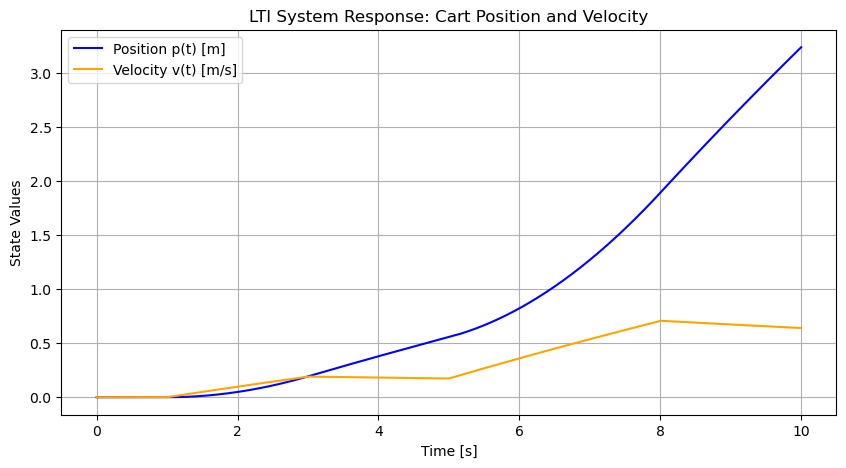

In [3]:
m0 = 10.0
b  = 0.5

# A, B, C matrices based on the derivation
A_lti = np.array([[0.0, 1.0], 
                  [0.0, -b/m0]])
B_lti = np.array([[0.0], 
                  [1.0/m0]])
C_lti = np.eye(2) 

# Simulation grid
dt_cart = 0.01
T_cart = 10.0
N_cart = int(T_cart / dt_cart)
t_cart = np.arange(N_cart + 1) * dt_cart

# Input u(t)
u = np.zeros(N_cart+1)
u[(t_cart >= 1) & (t_cart <= 3)] = 1.0
u[(t_cart >= 5) & (t_cart <= 8)] = 2.0

# Simulate x_{k+1} = x_k + dt*(A x_k + B u_k) (Euler integration)
x_lti = np.zeros((N_cart+1, 2))
x_lti[0, :] = [0.0, 0.0]

for k in range(N_cart):
    xk = x_lti[k, :].reshape(2, 1)
    uk = u[k]
    
    # Compute the state derivative (xdot)
    xdot = A_lti @ xk + B_lti * uk
    
    #  Update the next state using Euler integration
    x_lti[k+1, :] = (xk + dt_cart * xdot).flatten()

y_lti = (C_lti @ x_lti.T).T  
p_lti, v_lti = y_lti[:, 0], y_lti[:, 1]

# Plot LTI results 
plt.figure(figsize=(10, 5))
plt.plot(t_cart, p_lti, label="Position p(t) [m]", color='blue')
plt.plot(t_cart, v_lti, label="Velocity v(t) [m/s]", color='orange')
plt.title("LTI System Response: Cart Position and Velocity")
plt.xlabel("Time [s]")
plt.ylabel("State Values")
plt.grid(True)
plt.legend()
plt.show()

We now consider a linear time-varying model in which the cart’s mass decreases over time, for example due to fuel consumption.

The system remains linear in the state and input, but the matrices now depend on time through the changing mass m(t), so it is linear time-varying rather than time-invariant.


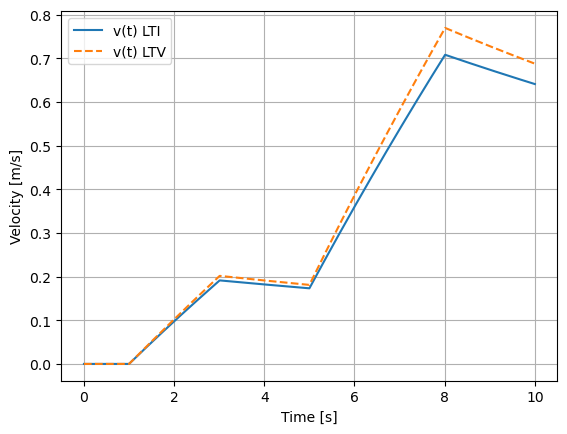

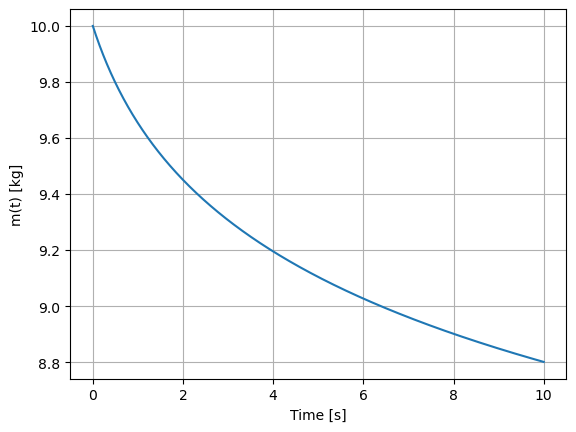

In [4]:
alpha = 0.5

def mass_function(t):
    # TODO define a decreasing mass function
    return max(1.0, m0 - alpha * np.log1p(t))

x_ltv = np.zeros((N_cart+1, 2))
x_ltv[0, :] = [0.0, 0.0]
for k in range(N_cart):
    mk = mass_function(t_cart[k])
    # TODO: define A and B for the current mass
    A = np.array([[0.0, 1.0],
                  [0.0, -b/mk]])
    B = np.array([[0.0],
                  [1.0/mk]])

    xk = x_ltv[k, :].reshape(2, 1)
    uk = u[k]
    
    # TODO: compute xdot = A @ xk + B * uk
    xdot = A @ xk + B * uk
    x_ltv[k+1, :] = (xk + dt_cart * xdot).flatten()

y_ltv = (C_lti @ x_ltv.T).T
p_ltv, v_ltv2 = y_ltv[:, 0], y_ltv[:, 1]

plt.figure()
plt.plot(t_cart, v_lti, label="v(t) LTI")
plt.plot(t_cart, v_ltv2, "--", label="v(t) LTV")
plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t_cart, np.array([mass_function(tt) for tt in t_cart]))
plt.xlabel("Time [s]")
plt.ylabel("m(t) [kg]")
plt.grid(True)
plt.show()

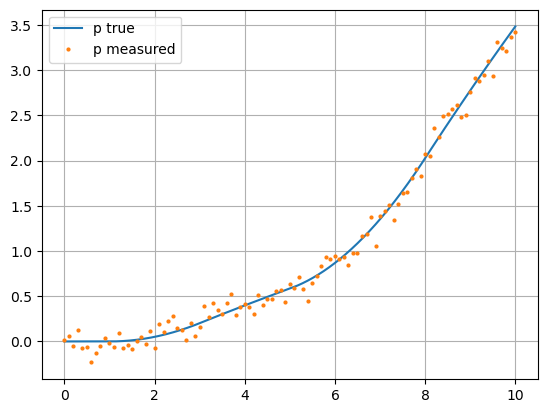

In [5]:
sigma_p = 1e-1
sigma_v = 1e-2

meas_dt = 0.1  # TODO  change measurement sampling rate
meas_stride = int(round(meas_dt / dt_cart))

rng = np.random.default_rng(0)

#Here we simulate sample sensor data points with noise plot the true trajectory and the measured trajectory points

y_true = y_ltv
y_meas = np.full_like(y_true, np.nan)

for k in range(N_cart+1):
    if k % meas_stride == 0:
        noise = rng.normal(loc=[0.0, 0.0], scale=[sigma_p, sigma_v])
        y_meas[k, :] = y_true[k, :] + noise

mask = ~np.isnan(y_meas[:, 0])

plt.figure()
plt.plot(t_cart, y_true[:, 0], label="p true")
plt.plot(t_cart[mask], y_meas[mask, 0], "o", markersize=2, label="p measured")
plt.grid(True)
plt.legend()
plt.show()

# Kalman Filter

Study the derivation of the Kalman gain from the recursive least-squares viewpoint to answer the following questions.

1. Why is the cost function chosen as  
   $W_k = \operatorname{tr}(P_k)$ ?  
   What is the physical meaning of minimizing the trace of the covariance?

2. Explain why the cross term  
   $E[e_{k-1} v_k^\top]$  
   equals zero in the derivation and what assumptions about the noise $v_k$ are necessary for the derivation?

3. Why does the measurement update typically reduce the estimation covariance? Under what role does process noise prevent the covariance from decreasing monotonically over time?




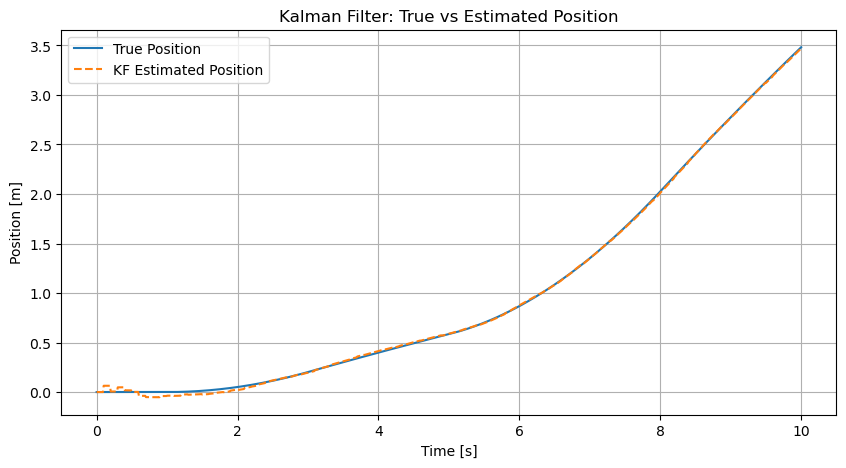

In [6]:
class KalmanFilter:
    def __init__(self, x0, P0, Q, R):
        self.x = x0.copy()
        self.P = P0.copy()
        self.Q = Q
        self.R = R

    def predict(self, A, B, u):
        # TODO  x^- = A x^+ + B u, P^- = A P^+ A^T + Q
        self.x = A @ self.x + B * u
        self.P = A @ self.P @ A.T + self.Q

    def update(self, C, y):
        # TODO  implement KF update
        # S = C P^- C^T + R
        # K = P^- C^T S^{-1}
        # x^+ = x^- + K (y - C x^-)
        # P^+ = (I - K C) P^-
        S = C @ self.P @ C.T + self.R
        K = self.P @ C.T @ np.linalg.inv(S)
        self.x = self.x + K @ (y - C @ self.x)
        self.P = (np.eye(self.P.shape[0]) - K @ C) @ self.P

# Initial conditions
x0 = np.array([[0.0], [0.0]])
P0 = np.diag([1.0, 1.0])

Q = np.diag([(1e-3)**2, (1e-2)**2])
R = np.diag([sigma_p**2, sigma_v**2])

kf = KalmanFilter(x0, P0, Q, R)

x_hat = np.zeros((N_cart+1, 2))
x_hat[0, :] = x0.flatten()

for k in range(N_cart):
    mk = max(mass_function(t_cart[k]), 1.0)

    A_c = np.array([[0.0, 1.0],
                    [0.0, -b/mk]])
    B_c = np.array([[0.0],
                    [1.0/mk]])

    # Discretise
    A_d = np.eye(2) + dt_cart * A_c
    B_d = dt_cart * B_c

    kf.predict(A_d, B_d, u[k])
    # If there is no measurement then do not update
    if not np.isnan(y_meas[k+1, 0]):
        yk = y_meas[k+1, :].reshape(2, 1)
        kf.update(C_lti, yk)

    x_hat[k+1, :] = kf.x.flatten()

# TODO Plot the true trajectory and the Kalman filter estimate
plt.figure(figsize=(10, 5))
plt.plot(t_cart, y_true[:, 0], label="True Position")
plt.plot(t_cart, x_hat[:, 0], "--", label="KF Estimated Position")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Kalman Filter: True vs Estimated Position")
plt.grid(True)
plt.legend()
plt.show()

# Extended Kalman Filter



Study the derivation of the Extended Kalman Filter (EKF) and answer the following questions.

To demonstrate the power of an EKF we use the very common example of the simple pendulum system. 




1. Starting from the a posteriori state update  
    $\hat{x}_k^+ = \hat{x}_k^- + K_k \big(y_k - c(\hat{x}_k^-)\big),$ 
    show that the “simple” covariance update is  
    $P_k^+ = (I - K_k C_k) P_k^-.$

    Explain why the Joseph form  
    $P_k^+ = (I - K_k C_k)\,P_k^-\,(I - K_k C_k)^\top + K_k R_k K_k^\top$
    is often preferred in numerical implementations.



2.  For a pendulum with state
    $x = \begin{bmatrix}\theta \\ \omega\end{bmatrix},$
    where $\omega = \dot{\theta}$, and dynamics
    $\dot{\theta} = \omega, \qquad \dot{\omega} = -\frac{g}{\ell}\sin\theta,$
    write explicit expressions for:
    - $f(x,u)$
    - $c(x)$
    - $F_k = \frac{\partial f}{\partial x}$
    - $C_k = \frac{\partial c}{\partial x}$
    needed to implement an EKF that estimates $\theta$ and $\omega$ from noisy angle measurements.


3. Explain why the linear Kalman filter is a special case of the extended Kalman filter.  
    Under what conditions does the EKF reduce exactly to the standard Kalman filter?


Assume the sensor measures a nonlinear function of the angle:
$z_k = \sin(\theta_k) + v_k$

C:\Users\ra3n24\AppData\Local\Temp\ipykernel_25328\444564270.py:139: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nis_vals.append(float(innov.T @ np.linalg.inv(S) @ innov))


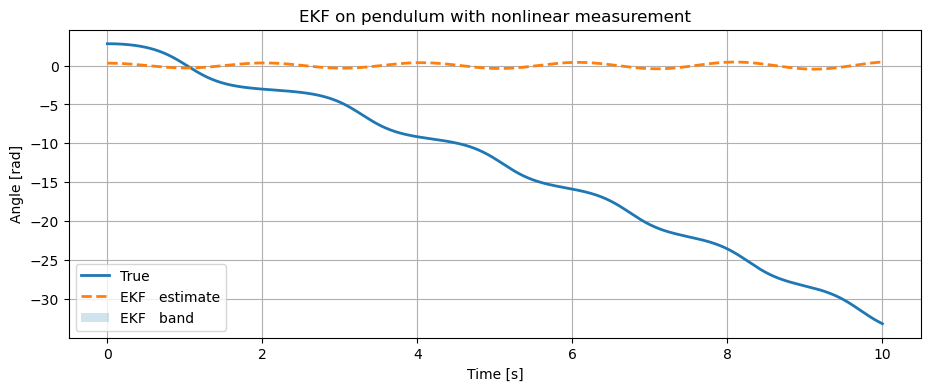

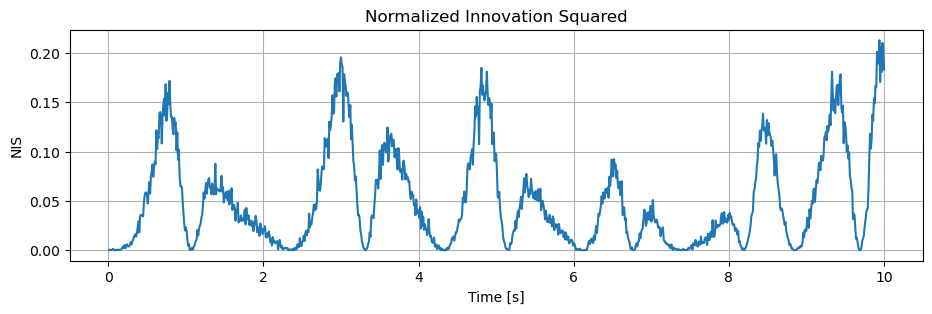

In [6]:
g = 9.81
ell = 1.0
dt_pend = 0.01
T_pend = 10.0
N_pend = int(T_pend / dt_pend)
t_pend = np.arange(N_pend + 1) * dt_pend
# True initial state
theta0_true = 2.8
omega0_true = 0.0

x_true = np.zeros((N_pend+1, 2))
x_true[0, :] = [theta0_true, omega0_true]

def pend_f_cont(x):
    """
    Continuous-time dynamics: x = [theta, omega]^T
    Returns x_dot.
    """
    theta = x[0, 0]
    omega = x[1, 0]

    # TODO implement
    # theta_dot = omega
    # omega_dot = -(g/ell)*sin(theta)
    theta_dot = omega
    omega_dot = -(g/ell) * np.sin(theta)

    return np.array([[theta_dot],
                     [omega_dot]])

def pend_f_discrete(x):
    """
    Discrete-time step (Euler):
    x_{k+1} = x_k + dt * f_cont(x_k)
    """
    # TODO implement Euler step
    return x + dt_pend * pend_f_cont(x)

def pend_F_jac(x):
    """
    Jacobian of discrete dynamics wrt x
    """
    theta = x[0, 0]

    # TODO (students): compute  f_cont/ x:
    # d/dx [theta_dot] = [0, 1]
    # d/dx [omega_dot] = [-(g/ell)cos(theta), 0]
    # then F = I + dt * J
    J = np.array([[0.0, 1.0],
                  [-(g/ell) * np.cos(theta), 0.0]])
    F = np.eye(2) + dt_pend * J

    return F

def h_meas(x):
    theta = x[0, 0]
    # implement measurement function
    return np.array([[np.sin(theta)]])

def H_jac(x):
    theta = x[0, 0]
    # Jacobian of h wrt x = [cos(theta), 0]
    return np.array([[np.cos(theta), 0.0]])

# Simulate truth
for k in range(N_pend):
    xk = x_true[k, :].reshape(2, 1)
    x_true[k+1, :] = pend_f_discrete(xk).flatten()

# Simulate noisy measurements
rng = np.random.default_rng(0)
sigma_meas = 0.05

z_meas = np.zeros(N_pend+1)
for k in range(N_pend+1):
    # TODO generate z_k = sin(theta_true_k) + noise
    z_meas[k] = np.sin(x_true[k, 0]) + rng.normal(0, sigma_meas)

# EKF implementation
class EKF:
    def __init__(self, x0, P0, Q, R):
        self.x = x0.copy()  # state estimate (2x1)
        self.P = P0.copy()  # covariance (2x2)
        self.Q = Q
        self.R = R

    def predict(self):
        # TODO  EKF predict step
        # F = pend_F_jac(self.x)
        # x^- = pend_f_discrete(self.x)
        # P^- = F P F^T + Q
        F = pend_F_jac(self.x)
        self.x = pend_f_discrete(self.x)
        self.P = F @ self.P @ F.T + self.Q

    def update(self, z):
        # TODO  EKF update step
        # H = H_jac(self.x)
        # y_hat = h_meas(self.x)
        # S = H P H^T + R
        # K = P H^T S^{-1}
        # x^+ = x^- + K (z - y_hat)
        # P^+ = (I - K H) P^-
        H = H_jac(self.x)
        y_hat = h_meas(self.x)
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ (z - y_hat)
        self.P = (np.eye(2) - K @ H) @ self.P

# Run EKF

x0 = np.array([[0.3],
               [0.0]])  # Intentionally overconfident and poorly initialized settings.
# Students should modify these and observe the effect.

# Try overconfident vs reasonable settings by changing these
P0 = np.diag([1e-10, 1e-10]) 
Q  = np.diag([1e-10, 1e-10]) 
R  = np.array([[10.0]])

ekf = EKF(x0, P0, Q, R)

x_hat = np.zeros((N_pend+1, 2))
x_hat[0, :] = x0.flatten()

theta_sigma = np.zeros(N_pend+1)
nis_vals = []

for k in range(N_pend):
    ekf.predict()

    z = np.array([[z_meas[k+1]]])

    # NIS computed from innovation statistics
    H = H_jac(ekf.x)
    S = H @ ekf.P @ H.T + ekf.R
    innov = z - h_meas(ekf.x)
    nis_vals.append(float(innov.T @ np.linalg.inv(S) @ innov))

    ekf.update(z)

    x_hat[k+1, :] = ekf.x.flatten()
    theta_sigma[k+1] = np.sqrt(ekf.P[0, 0])

# Plot results

theta_true = x_true[:, 0]
theta_est  = x_hat[:, 0]

plt.figure(figsize=(11, 4))
plt.plot(t_pend, theta_true, label="True  ", linewidth=2)
plt.plot(t_pend, theta_est, "--", label="EKF   estimate", linewidth=2)
plt.fill_between(t_pend, theta_est - 2*theta_sigma, theta_est + 2*theta_sigma, alpha=0.2,
                 label="EKF   band")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("EKF on pendulum with nonlinear measurement")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 3))
plt.plot(t_pend[1:], nis_vals, linewidth=1.5)
plt.xlabel("Time [s]")
plt.ylabel("NIS")
plt.title("Normalized Innovation Squared")
plt.grid(True)
plt.show()

4. Adjust the process noise and measurement noise to study how the EKF estimate varies. Interpret the results and include a plot in your report.


OPTIONAL Section

In [ ]:
def build_rounded_rect_track(Lx=60.0, Ly=40.0, r=10.0, n_straight=80, n_arc=60):

    Lx2, Ly2 = Lx/2, Ly/2
    r = min(r, Lx2, Ly2)

    xb = np.linspace(-Lx2+r,  Lx2-r, n_straight, endpoint=False)
    yb = np.full_like(xb, -Ly2)

    yr = np.linspace(-Ly2+r,  Ly2-r, n_straight, endpoint=False)
    xr = np.full_like(yr,  Lx2)

    xt = np.linspace( Lx2-r, -Lx2+r, n_straight, endpoint=False)
    yt = np.full_like(xt,  Ly2)

    yl = np.linspace( Ly2-r, -Ly2+r, n_straight, endpoint=False)
    xl = np.full_like(yl, -Lx2)

    def arc(cx, cy, th0, th1):
        th = np.linspace(th0, th1, n_arc, endpoint=False)
        return cx + r*np.cos(th), cy + r*np.sin(th)

    xbr, ybr = arc( Lx2-r, -Ly2+r, -np.pi/2, 0.0)
    xtr, ytr = arc( Lx2-r,  Ly2-r, 0.0, np.pi/2)
    xtl, ytl = arc(-Lx2+r,  Ly2-r, np.pi/2, np.pi)
    xbl, ybl = arc(-Lx2+r, -Ly2+r, np.pi, 3*np.pi/2)

    x = np.concatenate([xb, xbr, xr, xtr, xt, xtl, xl, xbl, [xb[0]]])
    y = np.concatenate([yb, ybr, yr, ytr, yt, ytl, yl, ybl, [yb[0]]])
    return np.vstack([x, y]).T
track = build_rounded_rect_track()

plt.figure()
plt.plot(track[:,0], track[:,1])
plt.axis('equal')
plt.grid(True)
plt.title("Track centerline")
plt.xlabel('x [m]')
plt.ylabel("y [m]")
plt.show()

Exploration task: Create a control system 

In [ ]:
dt_track = 0.2
T_track = 700.0
N_track = int(T_track / dt_track)
t_track = np.linspace(0, T_track, N_track + 1)

m0 = 900.0         # kg 
b_base = 35.0      # friction-like coefficient
fuel_burn = 1  # kg/min

def mass_function_racecar(t_sec):
    m = m0 - fuel_burn*(t_sec/60.0)
    return max(750.0, m)

def drs_active(px, py, vx, vy):

    """
    Open DRS on the two long straights
    when speed is above a threshold.
    """
    speed = np.hypot(vx, vy)
    on_straight = (abs(py) > 18.0)   
    return (on_straight and speed > 18.0)

def drag_coefficient(px, py, vx, vy, b_base):
    speed = np.hypot(vx, vy)
    # DRS is active if on straights and speed is high
    is_active = (abs(py) > 18.0) and (speed > 18.0)
    return b_base * (0.65 if is_active else 1.0)

def dynamics_matrices(m, b):

    """
    Continuous-time A_c, B_c for state [px, py, vx, vy] and input [Fx, Fy].
    """
    A_c = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, -b/m, 0],
    [0, 0, 0, -b/m]
    ], dtype=float)

    B_c = np.array([
        [0,   0],
        [0,   0],
        [1/m, 0],
        [0, 1/m]
    ], dtype=float)

    A_d = np.eye(4) + dt_track*A_c
    B_d = dt_track*B_c
    return A_c, B_c, A_d, B_d


## Dead Reckoning + Kalman Filter on a Race Track

You are given a 2D vehicle model state $x=[p_x,p_y,v_x,v_y]$ and a track centerline. Your job is to simulate motion, generate noisy sensors, then estimate position using dead reckoning and a Kalman filter.

What to implement

1. Controller + Simulation

    - Simulate the vehicle forward using $A_d, B_d$ from dynamics_matrices(m,b) and the time-varying mass_function and drag_coefficient.

2. Sensors

    - Generate odometry measurements of velocity $[v_x,v_y]$ with noise and bias (every timestep).
    - Generate GPS measurements of position $[p_x,p_y]$

3. Dead Reckoning

    - Implement dead reckoning using odometry:
    - $\hat p_{k+1}=\hat p_k + \Delta t\,\tilde v_{k+1}$
    - Plot true trajectory vs dead reckoning.

4. Kalman Filter

    - Implement a KF for $x=[p_x,p_y,v_x,v_y]$.
    - Update with odometry
    - Plot true trajectory vs KF estimate vs dead reckoning.

5. Questions 

    - Why does dead reckoning drift over time?
    - What happens if you increase odometry bias or reduce GPS dropout rate—does the KF still help? Why?
